# Cross-Species Fruit Quality Grading via Few-Shot Prototypical Networks

**Author:** Amr Samir  
**Master's Thesis – 2026**

---

**Research Gap:** While models can classify fruit species, they fail to generalize quality grading (Good/Bad) across unseen fruit types.  
**Key Contribution:** Train on {Apple, Banana, Grape} → Test on {Mango, Orange} WITHOUT retraining.

In [1]:
import os, sys, random, warnings
import numpy as np
import torch
warnings.filterwarnings('ignore')

# Ensure the repo root is on the path so `src` and `config` are importable
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from config import Config, ensure_dirs
from src.transforms import build_transforms
from src.dataset import FruitQualityDataset, EpisodicDataLoader
from src.models import PrototypicalNetwork
from src.losses import PrototypicalLoss
from src.train import train_protonet, evaluate, load_checkpoint
from src.visualization import (
    plot_training_history, visualize_embeddings,
    plot_confusion_matrices, plot_ablation_nshot,
)
from src.experiments import (
    test_on_unseen_fruits, ablation_n_shot,
    run_all_fsl_baselines, backbone_ablation,
    run_single_species_baselines,
    species_split_cross_validation,
    statistical_significance_tests,
    component_ablation,
    collect_dataset_statistics,
    generate_thesis_summary, generate_latex_tables,
)

# ── Reproducibility ──
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

config = Config()
ensure_dirs(config)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.5.1+cu121


## 1 · Dataset Statistics

In [2]:
dataset_stats = collect_dataset_statistics(
    config.DATA_ROOT, config.TRAIN_FRUITS, config.TEST_FRUITS, config.CLASSES
)

DATASET STATISTICS

TRAINING SET (Seen Fruits):
--------------------------------------------------
  APPLE: fresh: 765 | rotten: 630
  BANANA: fresh: 749 | rotten: 632
  GRAPE: fresh: 770 | rotten: 630

  TOTAL TRAINING: 4176 images

TEST SET (Unseen Fruits):
--------------------------------------------------
  MANGO: fresh: 763 | rotten: 630
  ORANGE: fresh: 753 | rotten: 656

  TOTAL TEST: 2802 images

SUMMARY: 6978 total images (train: 4176, test: 2802) | Fresh: 3800, Rotten: 3178


## 2 · Build Transforms & Datasets

In [3]:
transforms_dict = build_transforms(config)
train_transform   = transforms_dict['train']
support_transform = transforms_dict['support']
eval_transform    = transforms_dict['eval']

# Training & validation (seen fruits)
train_dataset = FruitQualityDataset(
    config.DATA_ROOT, config.TRAIN_FRUITS,
    support_transform=support_transform, query_transform=train_transform,
    split='train', val_ratio=config.VAL_SPLIT_RATIO, seed=42,
)
val_dataset = FruitQualityDataset(
    config.DATA_ROOT, config.TRAIN_FRUITS,
    support_transform=eval_transform, query_transform=eval_transform,
    split='val', val_ratio=config.VAL_SPLIT_RATIO, seed=42,
)

# Test (unseen fruits)
test_dataset = FruitQualityDataset(
    config.DATA_ROOT, config.TEST_FRUITS,
    support_transform=eval_transform, query_transform=eval_transform,
    split='all',
)

print(f'Train fruits: {config.TRAIN_FRUITS}')
print(f'Test  fruits: {config.TEST_FRUITS}')

  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten
  [all  ] Loaded  763 images: mango/fresh
  [all  ] Loaded  630 images: mango/rotten
  [all  ] Loaded  753 images: orange/fresh
  [all  ] Loaded  656 images: orange/rotten
Train fruits: ['apple', 'banana', 'grape']
Test  fruits: ['mango', 'orange']


## 3 · Build Model & Train

In [4]:
model = PrototypicalNetwork(
    backbone=config.BACKBONE,
    embedding_dim=config.EMBEDDING_DIM,
    pretrained=config.PRETRAINED,
    dropout_rate=config.DROPOUT_RATE,
    temperature=config.TEMPERATURE,
).to(device)

criterion = PrototypicalLoss(
    label_smoothing=config.LABEL_SMOOTHING,
    contrastive_weight=config.CONTRASTIVE_WEIGHT,
    temperature=config.TEMPERATURE,
)

train_loader = EpisodicDataLoader(
    train_dataset, config.N_SHOT, config.N_QUERY, config.N_EPISODES_TRAIN,
)
val_loader = EpisodicDataLoader(
    val_dataset, config.N_SHOT, config.N_QUERY, config.N_EPISODES_VAL,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {trainable:,} trainable / {total:,} total')

Model parameters: 6,765,569 trainable / 11,571,521 total


In [5]:
history = train_protonet(model, train_loader, val_loader, criterion, config, device)

TRAINING WITH WARMUP AND EARLY STOPPING



Epoch 1/30 [WARMUP]
  Train: Loss=0.9331, Acc=0.805
  Val:   Acc=0.886 | Gap=-0.080 | Temp=0.495
  LR:    1.67e-06
  -> Best model saved


  -> Best model saved



Epoch 5/30 [GOOD]
  Train: Loss=0.5924, Acc=0.955
  Val:   Acc=0.887 | Gap=+0.068 | Temp=0.482
  LR:    4.98e-06


  -> Best model saved


...

  -> Best model saved



Epoch 15/30 [GOOD]
  Train: Loss=0.5290, Acc=0.985
  Val:   Acc=0.942 | Gap=+0.044 | Temp=0.507
  LR:    3.22e-06
  -> Best model saved


  -> Best model saved



Epoch 20/30 [GOOD]
  Train: Loss=0.5230, Acc=0.988
  Val:   Acc=0.928 | Gap=+0.059 | Temp=0.517
  LR:    1.78e-06



Early stopping at epoch 22
  Best val acc: 0.942 @ epoch 15

TRAINING SUMMARY
Best validation accuracy: 0.943
Final train/val gap:      +0.046
  -> Best model weights restored.


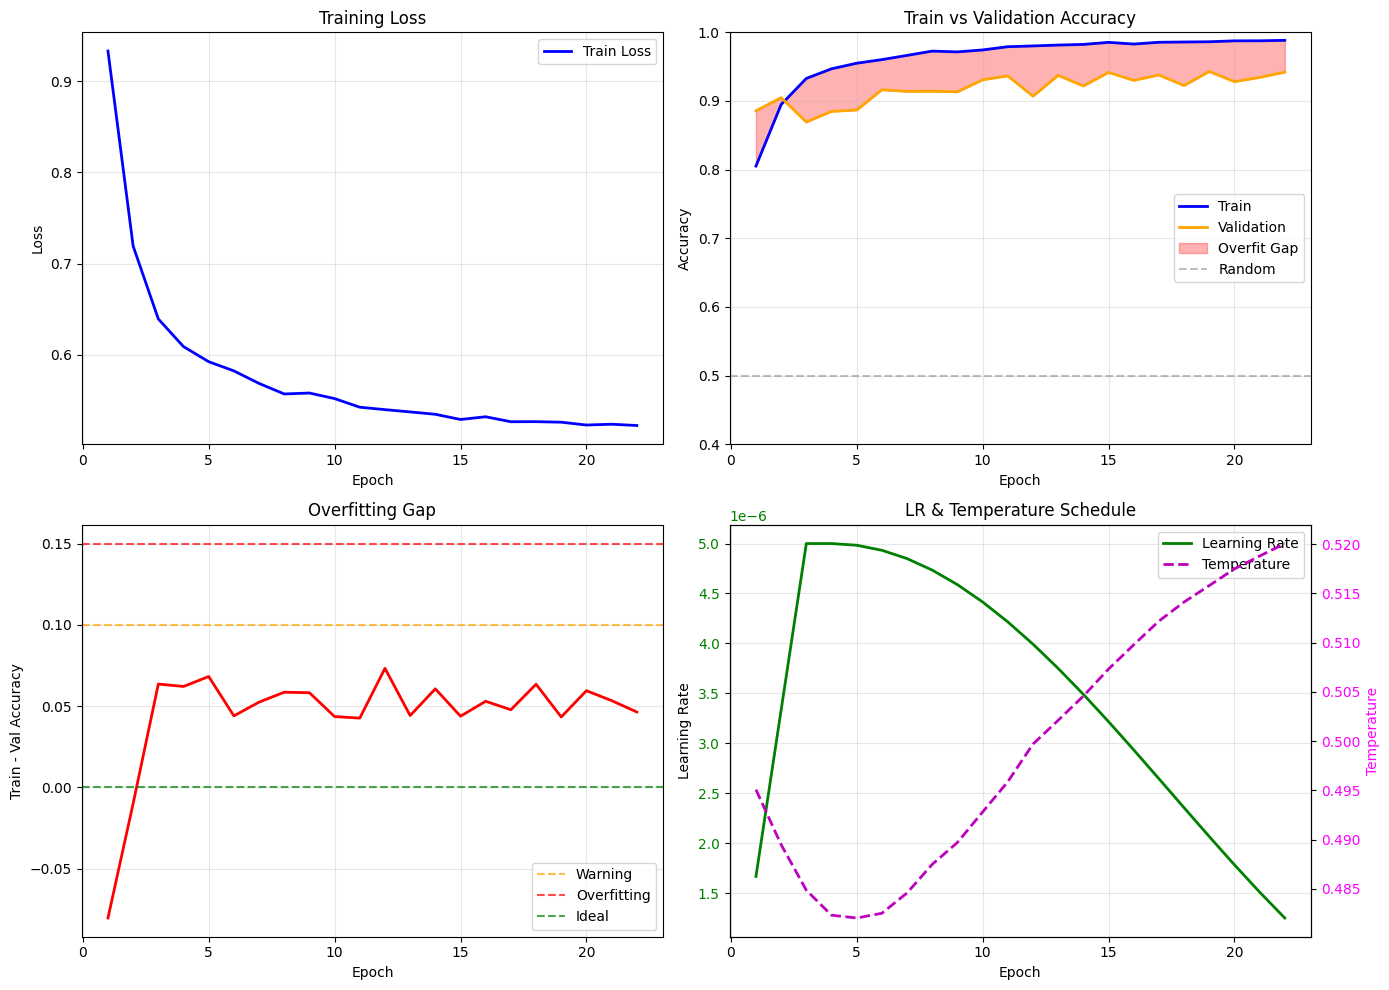

  Saved to C:\Users\admin\Desktop\Amr Samir\Final\training_curves.png


In [6]:
plot_training_history(history, config)

## 4 · Evaluate on Unseen Fruits

In [7]:
main_results = test_on_unseen_fruits(model, test_dataset, device, config, n_trials=5)

Testing on unseen fruits...



Overall: 85.4% +/- 0.4%


## 5 · Embedding Visualisation (t-SNE)

  File "C:\Users\admin\anaconda3\envs\torch-gpu\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


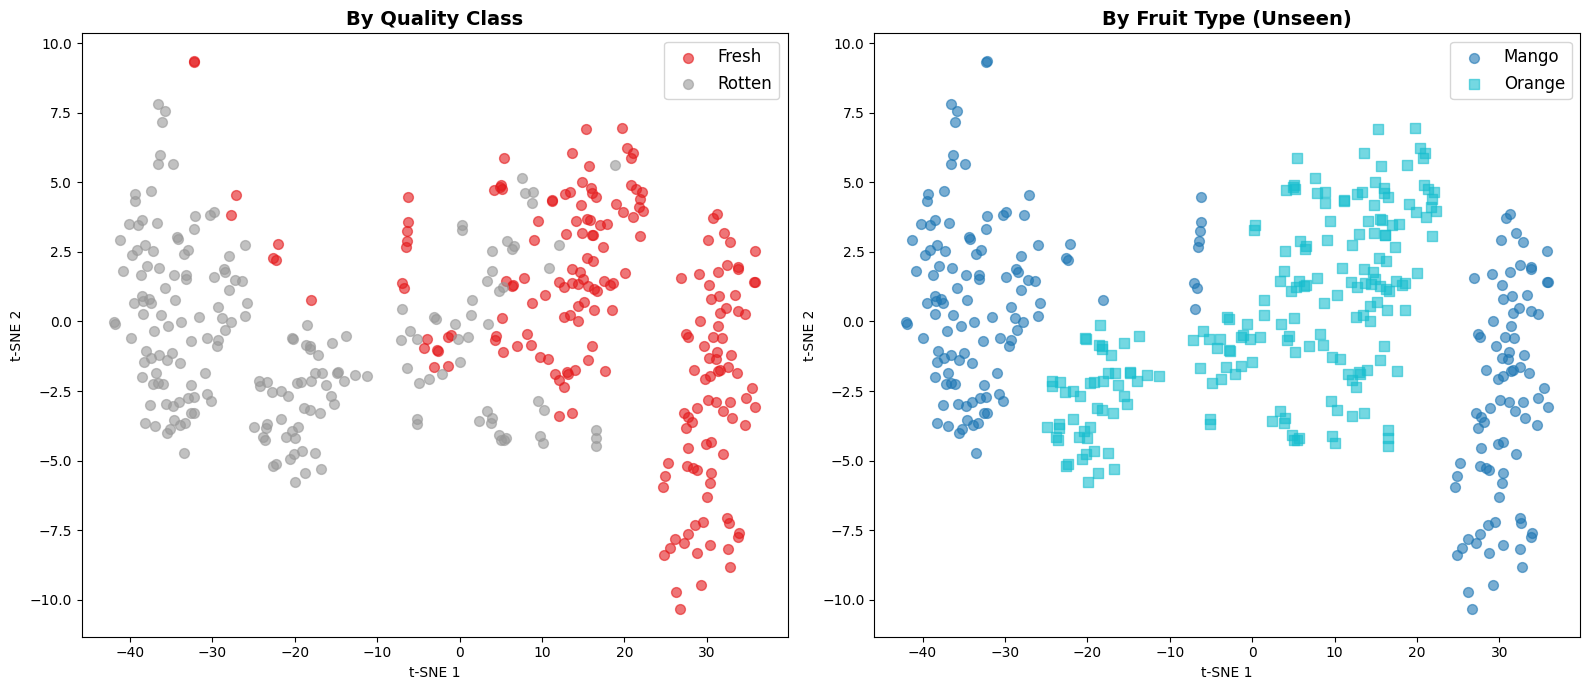

  Silhouette: 0.480  |  5-NN purity: 0.965


In [8]:
emb2d, labels, fruits = visualize_embeddings(
    model, test_dataset, eval_transform, device, config
)

## 6 · Confusion Matrices

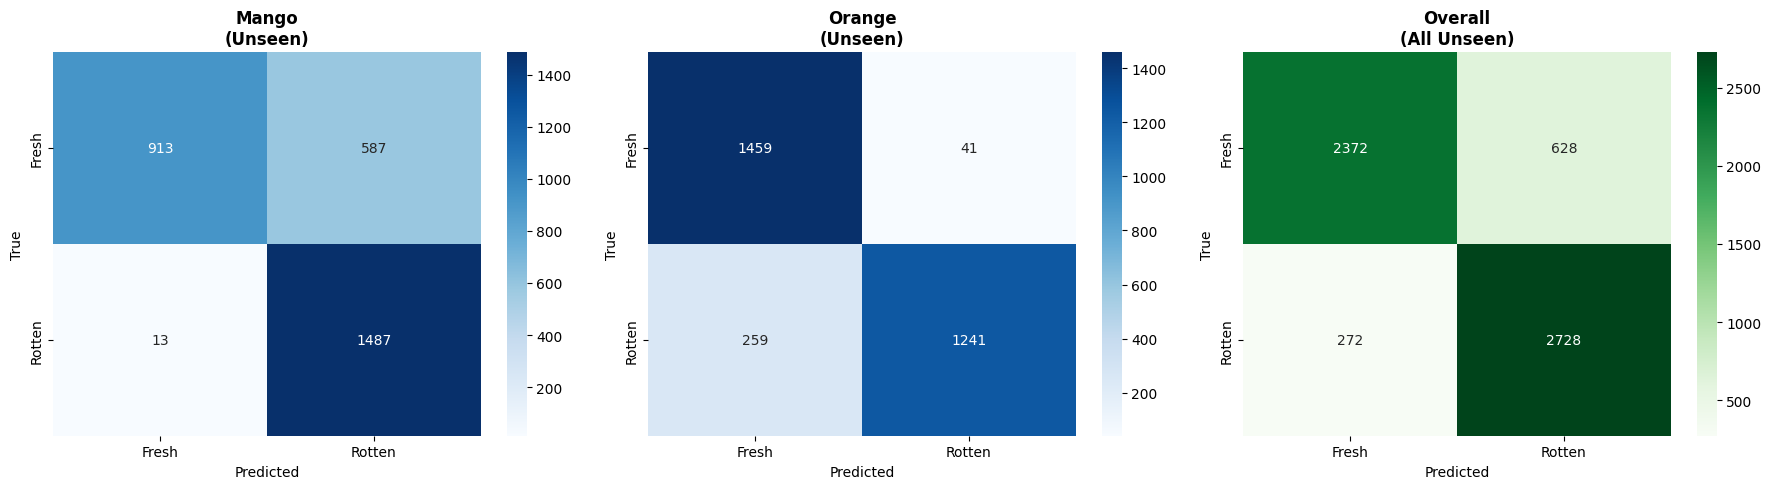


Classification Report (All Unseen Fruits):
              precision    recall  f1-score   support

       Fresh       0.90      0.79      0.84      3000
      Rotten       0.81      0.91      0.86      3000

    accuracy                           0.85      6000
   macro avg       0.85      0.85      0.85      6000
weighted avg       0.85      0.85      0.85      6000



In [9]:
cm = plot_confusion_matrices(model, test_dataset, device, config)

## 7 · N-Shot Ablation Study

Running N-shot ablation study...

  Testing 1-shot...


    1-shot: 83.5% +/- 0.7%

  Testing 3-shot...


    3-shot: 85.4% +/- 1.4%

  Testing 5-shot...


    5-shot: 85.6% +/- 0.7%

  Testing 10-shot...


    10-shot: 85.7% +/- 0.4%


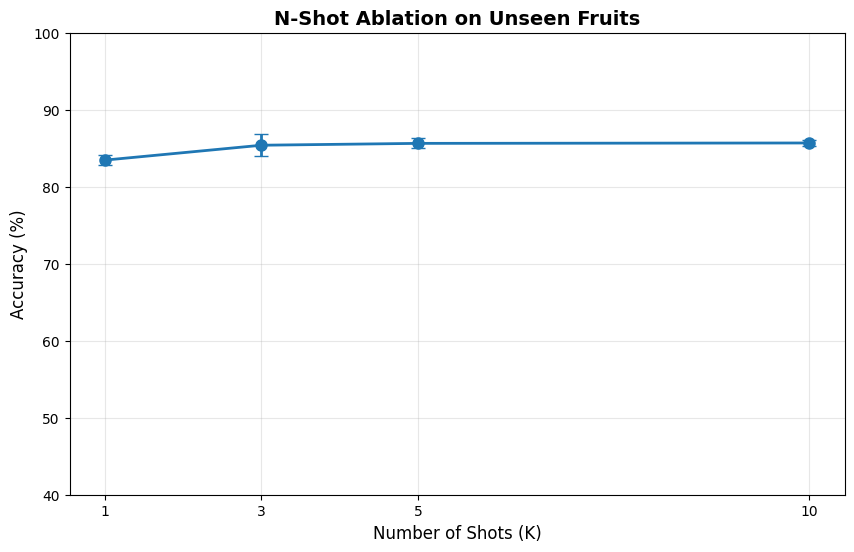

In [10]:
nshot_results = ablation_n_shot(model, test_dataset, device, config)
plot_ablation_nshot(nshot_results, config)

## 8 · Baseline Comparisons

In [11]:
baseline_results = run_all_fsl_baselines(
    model, train_dataset, val_dataset, test_dataset, config, device
)

Computing Nearest Centroid (pixel) baseline...


  Nearest Centroid: 69.6%

  Training baseline: Siamese Network


  Epoch   1 | Train 0.920 | Val 0.880 | Best 0.880


  Epoch   5 | Train 0.980 | Val 0.887 | Best 0.905


  Early stopping at epoch 9


...

  Epoch  10 | Train 0.996 | Val 0.951 | Best 0.951


  Epoch  15 | Train 0.997 | Val 0.946 | Best 0.954


  Early stopping at epoch 19



  ProtoNet + Temp. Scaling Test Accuracy: 83.4%
    orange: 95.7%
    mango: 71.4%

Evaluating our full model...



  Method                           Accuracy     95% CI
  -------------------------------------------------------
  Nearest Centroid (pixels)           69.6%       0.8%
  Siamese Network                     88.0%       0.5%
  Matching Network                    88.2%       0.8%
  ProtoNet (standard)                 76.1%       0.9%
  ProtoNet + Temp. Scaling            83.4%       1.1%
  Ours (Full Model)                   85.6%       0.7% ***


## 9 · Statistical Significance Tests

In [12]:
sig_table = statistical_significance_tests(baseline_results)

  STATISTICAL SIGNIFICANCE TESTS  (n = 600 episodes)
  Baseline                         t-stat      p (t)   W-stat      p (W)   Sig?
  ------------------------------------------------------------------------
  Nearest Centroid (pixels)         29.24  1.99e-117   170308   9.00e-86    Yes
  Siamese Network                   -5.51   5.37e-08    49830   1.00e+00     No
  Matching Network                  -4.97   8.61e-07    55858   1.00e+00     No
  ProtoNet (standard)               16.16   5.12e-49   124904   2.65e-41    Yes
  ProtoNet + Temp. Scaling           3.30   1.02e-03    89947   1.89e-04    Yes


## 10 · Backbone Ablation

In [13]:
backbone_results = backbone_ablation(
    train_dataset, val_dataset, test_dataset, config, device
)


  Backbone Ablation: resnet18


  Epoch 5 | Train 0.962 | Val 0.901


  Epoch 10 | Train 0.979 | Val 0.931


  Epoch 15 | Train 0.982 | Val 0.940


  Epoch 20 | Train 0.988 | Val 0.935


...

  Epoch 10 | Train 0.977 | Val 0.911


  Epoch 15 | Train 0.985 | Val 0.897


  Epoch 20 | Train 0.988 | Val 0.927


  Epoch 25 | Train 0.987 | Val 0.930
  Early stopping at epoch 25


  efficientnet_b0: 92.3% +/- 0.4%
    orange: 93.4%
    mango: 91.2%

  BACKBONE ABLATION SUMMARY
  Backbone               Accuracy     95% CI          Params
  ------------------------------------------------------------
  resnet18                  85.7%       0.6%    6,765,569
  resnet50                  86.8%       0.8%   20,164,353
  efficientnet_b0           92.3%       0.4%    4,793,397


## 11 · Single-Species Baselines

In [14]:
single_sp_results = run_single_species_baselines(
    model, test_dataset, transforms_dict, config, device
)


  SINGLE-SPECIES BASELINES (Table 4)

  Training on [apple] only ...
  [train] Loaded  651 images: apple/fresh
  [train] Loaded  536 images: apple/rotten
  [val  ] Loaded  114 images: apple/fresh
  [val  ] Loaded   94 images: apple/rotten


    Early stopping at epoch 10


    apple-trained -> unseen: 87.6% +/- 0.6%

  Training on [banana] only ...
  [train] Loaded  637 images: banana/fresh
  [train] Loaded  538 images: banana/rotten
  [val  ] Loaded  112 images: banana/fresh
  [val  ] Loaded   94 images: banana/rotten


    Early stopping at epoch 8


    banana-trained -> unseen: 90.9% +/- 0.6%

  Training on [grape] only ...
  [train] Loaded  655 images: grape/fresh
  [train] Loaded  536 images: grape/rotten
  [val  ] Loaded  115 images: grape/fresh
  [val  ] Loaded   94 images: grape/rotten


    Early stopping at epoch 10


    grape-trained -> unseen: 78.1% +/- 1.1%



  Training Species            Accuracy     95% CI
  --------------------------------------------------
  Apple-trained                  87.6%       0.6%
  Banana-trained                 90.9%       0.6%
  Grape-trained                  78.1%       1.1%
  Multi-species (Ours)           85.0%       0.7% ***


## 12 · Species-Split Cross-Validation

In [12]:
cv_results = species_split_cross_validation(transforms_dict, config, device)

  SPECIES-SPLIT CROSS-VALIDATION  (C(5,3) = 10 leave-2-species-out folds)
   #  Train                      Test (unseen)            Accuracy
  ------------------------------------------------------------------
   1  apple, banana, grape       mango, orange           85.3% +/- 0.6%
   2  apple, banana, mango       grape, orange           76.3% +/- 0.9%
   3  apple, banana, orange      grape, mango            79.7% +/- 0.7%
   4  apple, grape, mango        banana, orange          87.2% +/- 0.6%
   5  apple, grape, orange       banana, mango           75.7% +/- 0.7%
   6  apple, mango, orange       banana, grape           82.6% +/- 0.8%
   7  banana, grape, mango       apple, orange           77.9% +/- 1.2%
   8  banana, grape, orange      apple, mango            79.5% +/- 0.7%
   9  banana, mango, orange      apple, grape            74.3% +/- 0.8%
  10  grape, mango, orange       apple, banana           80.6% +/- 0.8%
  ------------------------------------------------------------------
 

## 13 · Component Ablation Study

In [13]:
ablation_results = component_ablation(
    model, train_dataset, val_dataset, test_dataset, config, device
)

  COMPONENT ABLATION STUDY (Table 6)
  Variant                     Accuracy    95% CI    Delta
  ------------------------------------------------------------
  Full Model                     85.7%      0.7%      ---
  - Contrastive Loss             86.5%      0.6%     +0.7
  - Temperature Scaling          80.5%      0.6%     -5.3
  - Frozen Layers                84.0%      0.9%     -1.7
  - Dropout                      89.1%      0.5%     +3.4


## 14 · Thesis Summary & LaTeX Tables

In [14]:
all_results = {
    'main_experiment': main_results,
    'ablation_nshot':  nshot_results,
    'baselines':       baseline_results,
}

generate_thesis_summary(all_results, dataset_stats, config)
generate_latex_tables(all_results, config)

COMPLETE THESIS RESULTS SUMMARY

--------------------------------------------------------------------------------
1. RESEARCH FOCUS
--------------------------------------------------------------------------------
  Task: Cross-Species Fruit Quality Grading
  Problem: Binary classification (Fresh vs Rotten) that generalizes to unseen fruits
  Method: Few-Shot Learning with Prototypical Networks
  Key Claim: Model trained on {Apple, Banana, Grape} generalizes to {Mango, Orange}

--------------------------------------------------------------------------------
2. DATASET STATISTICS
--------------------------------------------------------------------------------
  Training Fruits (Seen): ['apple', 'banana', 'grape']
  Test Fruits (Unseen):   ['mango', 'orange']
  Classes: Fresh vs Rotten
  Total Training Images:  4176
  Total Test Images:      2802

--------------------------------------------------------------------------------
3. MAIN RESULTS: Cross-Species Generalization
----------------